# Data Quality Assessment

Comprehensive quality control of multi-omics dataset including RNA-seq, proteomics, and metabolomics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import gaussian_kde

plt.style.use('default')
sns.set_palette('Set2')
primary_green = '#2E8B57'
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
rnaseq_stats = pd.read_csv('../results/omics_qc/rnaseq_per_patient_stats.csv')
proteomics_stats = pd.read_csv('../results/omics_qc/proteomics_per_patient_completeness.csv')
metabolomics_cov = pd.read_csv('../results/omics_qc/metabolomics_coverage.csv')
recon3d_coverage = pd.read_csv('../results/omics_qc/omics_recon3d_coverage_summary.csv')

graph_summary = pd.read_csv('../results/graph_statistics/graph_structure_summary.csv')
node_degree = pd.read_csv('../results/graph_statistics/node_degree_distribution.csv')
currency_mets = pd.read_csv('../results/graph_statistics/currency_metabolites.csv')

print('Data files loaded successfully.')
print(f'RNA-seq stats: {rnaseq_stats.shape}')
print(f'Proteomics stats: {proteomics_stats.shape}')

Data files loaded successfully.
RNA-seq stats: (219, 5)
Proteomics stats: (219, 3)


## RNA-seq Data Quality

In [3]:
print('\n=== RNA-SEQ QUALITY METRICS ===')
print(f'Number of patients: {rnaseq_stats.shape[0]}')
print(f'\nExpressed genes per patient:')
print(f'  Mean: {rnaseq_stats["n_expressed_genes"].mean():.0f} +/- {rnaseq_stats["n_expressed_genes"].std():.0f}')
print(f'  Min: {rnaseq_stats["n_expressed_genes"].min():.0f}')
print(f'  Max: {rnaseq_stats["n_expressed_genes"].max():.0f}')
print(f'\nVST-transformed expression (median per patient):')
print(f'  Mean: {rnaseq_stats["median_vst"].mean():.2f} +/- {rnaseq_stats["median_vst"].std():.2f}')
print(f'  Min: {rnaseq_stats["median_vst"].min():.2f}')
print(f'  Max: {rnaseq_stats["median_vst"].max():.2f}')


=== RNA-SEQ QUALITY METRICS ===
Number of patients: 219

Expressed genes per patient:
  Mean: 17400 +/- 1433
  Min: 15024
  Max: 19805

VST-transformed expression (median per patient):
  Mean: 7.72 +/- 1.64
  Min: 2.93
  Max: 12.75


## Proteomics Data Quality

In [4]:
print('\n=== PROTEOMICS QUALITY METRICS ===')
print(f'Number of patients: {proteomics_stats.shape[0]}')
print(f'\nQuantified proteins per patient:')
print(f'  Mean: {proteomics_stats["n_quantified"].mean():.0f} +/- {proteomics_stats["n_quantified"].std():.0f}')
print(f'\nProteomics data completeness:')
print(f'  Mean: {proteomics_stats["pct_complete"].mean():.2f}% +/- {proteomics_stats["pct_complete"].std():.2f}%')
print(f'  Patients >= 70% complete: {(proteomics_stats["pct_complete"] >= 70).sum()}/{len(proteomics_stats)}')


=== PROTEOMICS QUALITY METRICS ===
Number of patients: 219

Quantified proteins per patient:
  Mean: 10568 +/- 444

Proteomics data completeness:
  Mean: 87.36% +/- 5.25%
  Patients >= 70% complete: 219/219


## Recon3D Coverage Summary

In [5]:
print('\n=== RECON3D MODEL COVERAGE ===')
print(recon3d_coverage.to_string(index=False))


=== RECON3D MODEL COVERAGE ===
 omics_layer  n_features_total  n_mapped_to_recon3d  pct_coverage
     RNA-seq             19812                 2248     11.346659
  Proteomics             11348                 1847     16.275996
Metabolomics               222                   11      4.954955


## Figure 2: Data Quality and Coverage Assessment

/sessions/beautiful-dreamy-ride/tmp/ipykernel_2895/345280391.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


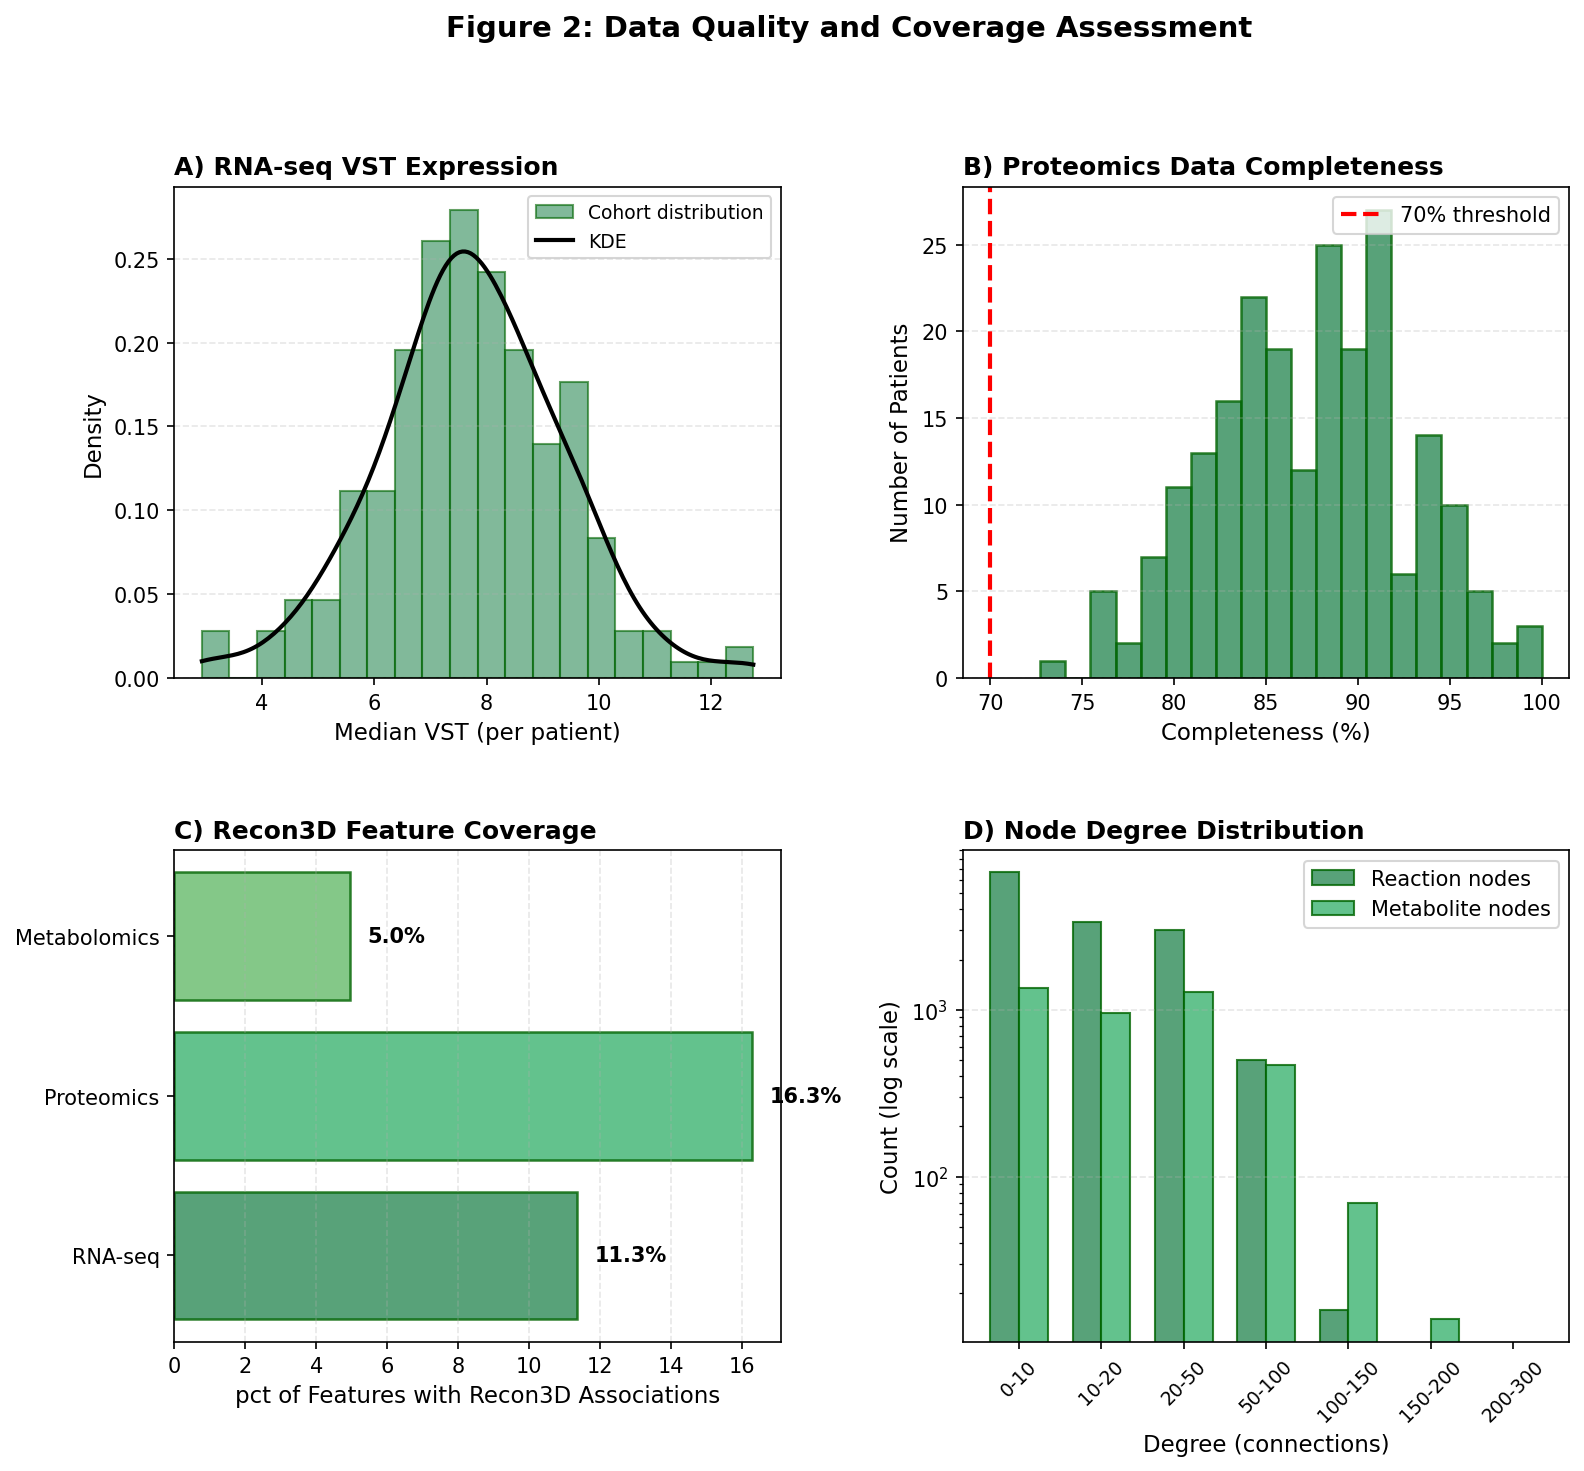

Figure 2 saved as Figure_2_Data_Quality.png


In [6]:
fig = plt.figure(figsize=(12, 10), dpi=150)
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Panel A: RNA-seq VST expression distribution
ax_a = fig.add_subplot(gs[0, 0])
ax_a.hist(rnaseq_stats['median_vst'], bins=20, density=True, alpha=0.6, color=primary_green, edgecolor='darkgreen', label='Cohort distribution')
kde = gaussian_kde(rnaseq_stats['median_vst'])
x_range = np.linspace(rnaseq_stats['median_vst'].min(), rnaseq_stats['median_vst'].max(), 200)
ax_a.plot(x_range, kde(x_range), 'k-', linewidth=2, label='KDE')
ax_a.set_title('A) RNA-seq VST Expression', fontsize=12, fontweight='bold', loc='left')
ax_a.set_xlabel('Median VST (per patient)', fontsize=11)
ax_a.set_ylabel('Density', fontsize=11)
ax_a.legend(fontsize=9, loc='upper right')
ax_a.grid(axis='y', alpha=0.3, linestyle='--')

# Panel B: Proteomics completeness
ax_b = fig.add_subplot(gs[0, 1])
ax_b.hist(proteomics_stats['pct_complete'], bins=20, color=primary_green, alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_b.axvline(70, color='red', linestyle='--', linewidth=2, label='70% threshold')
ax_b.set_title('B) Proteomics Data Completeness', fontsize=12, fontweight='bold', loc='left')
ax_b.set_xlabel('Completeness (%)', fontsize=11)
ax_b.set_ylabel('Number of Patients', fontsize=11)
ax_b.legend(fontsize=10)
ax_b.grid(axis='y', alpha=0.3, linestyle='--')

# Panel C: Recon3D coverage
ax_c = fig.add_subplot(gs[1, 0])
omics_layers = ['RNA-seq', 'Proteomics', 'Metabolomics']
coverage_pcts = [11.35, 16.28, 4.95]
colors_coverage = ['#2E8B57', '#3CB371', '#66BB6A']
bars = ax_c.barh(omics_layers, coverage_pcts, color=colors_coverage, alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_c.set_title('C) Recon3D Feature Coverage', fontsize=12, fontweight='bold', loc='left')
ax_c.set_xlabel('pct of Features with Recon3D Associations', fontsize=11)
ax_c.grid(axis='x', alpha=0.3, linestyle='--')
for i, (bar, pct) in enumerate(zip(bars, coverage_pcts)):
    ax_c.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontweight='bold', fontsize=10)

# Panel D: Node degree distribution
ax_d = fig.add_subplot(gs[1, 1])
x_pos = np.arange(len(node_degree))
width = 0.35
bars1 = ax_d.bar(x_pos - width/2, node_degree['count_reaction_nodes'], width, label='Reaction nodes', color='#2E8B57', alpha=0.8, edgecolor='darkgreen')
bars2 = ax_d.bar(x_pos + width/2, node_degree['count_metabolite_nodes'], width, label='Metabolite nodes', color='#3CB371', alpha=0.8, edgecolor='darkgreen')
ax_d.set_title('D) Node Degree Distribution', fontsize=12, fontweight='bold', loc='left')
ax_d.set_xlabel('Degree (connections)', fontsize=11)
ax_d.set_ylabel('Count (log scale)', fontsize=11)
ax_d.set_xticks(x_pos)
ax_d.set_xticklabels(node_degree['degree_bin'], rotation=45, fontsize=9)
ax_d.set_yscale('log')
ax_d.legend(fontsize=10, loc='upper right')
ax_d.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Figure 2: Data Quality and Coverage Assessment', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('Figure_2_Data_Quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved as Figure_2_Data_Quality.png')

## Graph Structure Summary

In [7]:
print('\n=== KNOWLEDGE GRAPH STRUCTURE ===')
print(graph_summary.to_string(index=False))

n_reactions = graph_summary[graph_summary['entity_type'] == 'Reaction nodes']['count'].values[0]
n_metabolites = graph_summary[graph_summary['entity_type'] == 'Metabolite nodes']['count'].values[0]
print(f'\nTotal nodes: {n_reactions + n_metabolites:,}')
print(f'  Reaction nodes: {n_reactions:,}')
print(f'  Metabolite nodes: {n_metabolites:,}')


=== KNOWLEDGE GRAPH STRUCTURE ===
            entity_type  count
         Reaction nodes  13543
       Metabolite nodes   4140
     substrate_of edges  29847
         produces edges  17471
shares_metabolite edges  41980
   Currency metabolites     15

Total nodes: 17,683
  Reaction nodes: 13,543
  Metabolite nodes: 4,140


## Currency Metabolites

In [8]:
print('\n=== CURRENCY METABOLITES ===')
print(f'Total currency metabolites: {len(currency_mets)}')
currency_mets_sorted = currency_mets.sort_values('degree', ascending=False)
print('\nTop currency metabolites by degree:')
print(currency_mets_sorted[['metabolite_id', 'name', 'degree']].to_string(index=False))


=== CURRENCY METABOLITES ===
Total currency metabolites: 15

Top currency metabolites by degree:
  metabolite_id       name  degree
CURRENCY_MET_08 Coenzyme A     342
CURRENCY_MET_09 Acetyl-CoA     333
CURRENCY_MET_15  Phosphate     298
CURRENCY_MET_10        GTP     294
CURRENCY_MET_07      FADH2     290
CURRENCY_MET_13      NADP+     272
CURRENCY_MET_11        GDP     247
CURRENCY_MET_05       NADH     219
CURRENCY_MET_14      NADPH     205
CURRENCY_MET_03        AMP     192
CURRENCY_MET_02        ADP     177
CURRENCY_MET_12        GMP     169
CURRENCY_MET_04       NAD+     164
CURRENCY_MET_06        FAD     154
CURRENCY_MET_01        ATP     152
